# Example notebook: Fisher forecast 

Authors: Ian Hothi & Adélie Gorce

Date: May 2025

In this notebook, we show how to obtain Fisher results from statistics pre-computed on the simulation dataset with the `compute_statistic` script.

In [1]:
import numpy as np
import h5py
import tqdm
import matplotlib.pyplot as plt
import corner

import os
import gc
import glob
import numpy as np

# About the data

The data has been simulated using 21cmFast. The XY plane has an extent of 250Mpc, with 256 pixels on each side. The line-of-sight (redshift) has been simulated to be between z = 8.82 (144.60 MHz) and z = 9.33 (137.46 MHz), comprising 128 frequency channels. The three parameters chosen to be changed are the virial temperature, maximum bubble size, and the ionising efficiency parameter—these were all found to have the strongest impact on the signal. 

These are the parameter variations (fiducial value $\pm$ change):

- $T_{Vir}$: $50000\pm 5000$
- $R_{Max}$: $15\pm 5 Mpc$
- $\zeta$: $30\pm 5$,
400 simulations were run for each parameter value, which will be used for the derivatives. In the loaded files, there will be two files for each parameter, one corresponding to the plus value - for example, for $T_{Vir}$ tue value would be 50000 + 5000. Whereas the minus value would be 50000 - 5000.


400 simulations were run with the fiducial values, this will serve to calculate the covariances of the statistics.




In [2]:
# Folder where the data is stored
ddir = '/travail/ihothi/SKA_chapter_simulations/'

In [3]:
statname = 'wst'

## Global parameters

In [4]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = [pow(10,4.7),15,30]
# parameter range for derivatives
delta_params = [pow(10,4.740362689494244)-pow(10,4.653212513775344), 10, 10]

# Power spectrum params
nbins = 15

In [5]:
# simulation files
files = [ddir+'Lightcone_FID_400_Samples.h5']
[files.extend(
    [f'{ddir}Lightcone_{p}_400_Samples_Plus.h5', f'{ddir}Lightcone_{p}_400_Samples_Minus.h5']) for p in params]
print(files)

['/travail/ihothi/SKA_chapter_simulations/Lightcone_FID_400_Samples.h5', '/travail/ihothi/SKA_chapter_simulations/Lightcone_ION_Tvir_MIN_400_Samples_Plus.h5', '/travail/ihothi/SKA_chapter_simulations/Lightcone_ION_Tvir_MIN_400_Samples_Minus.h5', '/travail/ihothi/SKA_chapter_simulations/Lightcone_R_BUBBLE_MAX_400_Samples_Plus.h5', '/travail/ihothi/SKA_chapter_simulations/Lightcone_R_BUBBLE_MAX_400_Samples_Minus.h5', '/travail/ihothi/SKA_chapter_simulations/Lightcone_HII_EFF_FACTOR_400_Samples_Plus.h5', '/travail/ihothi/SKA_chapter_simulations/Lightcone_HII_EFF_FACTOR_400_Samples_Minus.h5']


Parameters describing the simulations:

In [6]:
# Read h5py file for metadata
with h5py.File(files[0], 'r') as f:
    frequencies = f['frequencies'][...]
    redshifts = f['redshifts'][...]
    box_length = float(f['box_length'][0])  # Mpc
    box_dim = int(f['ngrid'][0])
    n_samp = int(f['nrealisations'][0])
nfreq = frequencies.size
print(f'Lightcone runs from z={redshifts.min():.2f} to z = {redshifts.max():.2f}.')

Lightcone runs from z=8.82 to z = 9.33.


Parameters for the forecast:

# Loading Data and Statistics estimation 

In [9]:
import os
import glob
import h5py
import numpy as np
import tqdm

files = sorted(glob.glob('/travail/ihothi/SKA_chapter_simulations/Lightcone*.h5'))
configs = ['aastar1000', 'aastar100', 'aa4']

WST_data = {}
for fpath in tqdm.tqdm(files, desc="Loading WST L1/L2 only"):
    key = os.path.basename(fpath).replace('Lightcone_', '').replace('.h5', '')
    with h5py.File(fpath, 'r') as f:
        freqs  = f['frequencies'][...]      
        n_samp = int(f['nrealisations'][0]) 
        entry  = {'freqs': freqs}

        # 1) probe for any existing *_l1l2 to get n_features
        n_features = None
        for suf in configs:
            name = f'wst_{suf}_l1l2'
            if name in f:
                example = f[name][...]                    # (400, n_features)
                n_features = example.shape[1]
                entry[name] = example
                break
        if n_features is None:
            raise KeyError(f"No wst_*_l1l2 found in {fpath}")

        # 2) now load or zero-fill all three cases
        for suf in configs:
            name = f'wst_{suf}_l1l2'
            if name not in entry:
                if name in f:
                    entry[name] = f[name][...]
                else:
                    entry[name] = np.zeros((n_samp, n_features), dtype=np.float32)

    WST_data[key] = entry

# Quick sanity check
for name, dat in WST_data.items():
    line = f"{name:15s}: freqs {dat['freqs'].shape}"
    for suf in configs:
        arr = dat[f'wst_{suf}_l1l2']
        line += f" | {suf:12s} l1l2 {arr.shape}"
    print(line)


Loading WST L1/L2 only: 100%|██████████| 7/7 [00:01<00:00,  3.82it/s]

FID_400_Samples: freqs (128,) | aastar1000   l1l2 (400, 55, 5) | aastar100    l1l2 (400, 55, 5) | aa4          l1l2 (400, 55, 5)
HII_EFF_FACTOR_400_Samples_Minus: freqs (128,) | aastar1000   l1l2 (400, 55, 5) | aastar100    l1l2 (400, 55, 5) | aa4          l1l2 (400, 55, 5)
HII_EFF_FACTOR_400_Samples_Plus: freqs (128,) | aastar1000   l1l2 (400, 55, 5) | aastar100    l1l2 (400, 55, 5) | aa4          l1l2 (400, 55, 5)
ION_Tvir_MIN_400_Samples_Minus: freqs (128,) | aastar1000   l1l2 (400, 55, 5) | aastar100    l1l2 (400, 55, 5) | aa4          l1l2 (400, 55, 5)
ION_Tvir_MIN_400_Samples_Plus: freqs (128,) | aastar1000   l1l2 (400, 55, 5) | aastar100    l1l2 (400, 55, 5) | aa4          l1l2 (400, 55, 5)
R_BUBBLE_MAX_400_Samples_Minus: freqs (128,) | aastar1000   l1l2 (400, 55, 5) | aastar100    l1l2 (400, 55, 5) | aa4          l1l2 (400, 55, 5)
R_BUBBLE_MAX_400_Samples_Plus: freqs (128,) | aastar1000   l1l2 (400, 55, 5) | aastar100    l1l2 (400, 55, 5) | aa4          l1l2 (400, 55, 5)


### Fisher Matrix

Under the assumption that the likelihood is a multivariate Gaussian (mean vectors are sufficient information for the covariance matrix), the Fisher matrix is defined as:

$$F^\theta_{ij} = \frac{\partial \textbf{S}}{\partial\theta_i} \mathbf{\Sigma}^{-1} \frac{\partial \textbf{S}}{\partial\theta_j},$$

where  $\frac{\partial \textbf{S}}{\partial\theta_i}$ is the change in statistic S under a change in paramrter i of $\partial\theta_j$. Here, $\mathbf{\Sigma}$ is the the covariance matrix, given my the fiducial simulation set.


Let us first calculate $\frac{\partial \textbf{S}}{\partial\theta_i}$ for out three astrophysical parameters:

In [28]:
WST_data = {k.replace('_400_Samples',''): v for k,v in WST_data.items()}

n_params      = len(params)
n_samp, n_feat = WST_data['FID']['wst_aastar1000_l1l2'].shape  # (400, n_features)

fields = ['wst_aastar1000_l1l2', 'wst_aastar100_l1l2', 'wst_aa4_l1l2']
derivs_all = {
    field: np.zeros((n_params, n_samp, n_feat), dtype=float)
    for field in fields
}

for ip, param in enumerate(params):
    plus_key  = f"{param}_Plus"
    minus_key = f"{param}_Minus"
    for field in fields:
        P = WST_data[plus_key][field]    # shape: (400, n_features)
        M = WST_data[minus_key][field]
        derivs_all[field][ip] = (P - M) / delta_params[ip]

freqs = WST_data[f'{params[0]}_Plus']['freqs']

#Quick check of shapes
for field in fields:
    print(f"{field:30s} derivs shape → {derivs_all[field].shape}")


wst_aastar1000_l1l2            derivs shape → (3, 400, 275)
wst_aastar100_l1l2             derivs shape → (3, 400, 275)
wst_aa4_l1l2                   derivs shape → (3, 400, 275)


Let us whiten the data to get rid of any order of magnitude issues that may arise:

In [26]:
import numpy as np

fiducial_key = 'FID_400_Samples'

fields = ['wst_aastar1000_l1l2',
          'wst_aastar100_l1l2',
          'wst_aa4_l1l2']

# prepare container
covs = {}

for field in fields:
    # 1) pull & flatten
    arr    = WST_data[fiducial_key][field]    # shape: (400, n_coeff, n_feats)
    n_samp = arr.shape[0]
    flat   = arr.reshape(n_samp, -1)          #(400, n_features)

    # 2) whiten
    std    = np.std(flat, axis=0)
    white  = flat / std                       #(400, n_features)

    # 3) build covariance
    covariance = np.cov(white, rowvar=False)  #(n_features, n_features)
    covs[field] = covariance                  # store it

    # 4) report condition
    cond = np.linalg.cond(covariance)
    print(f"{field:30s} → log10(cond) = {np.log10(cond):.2f} (should be ≤ 7)")


wst_aastar1000_l1l2            → log10(cond) = 4.83 (should be ≤ 7)
wst_aastar100_l1l2             → log10(cond) = 4.68 (should be ≤ 7)
wst_aa4_l1l2                   → log10(cond) = 4.36 (should be ≤ 7)


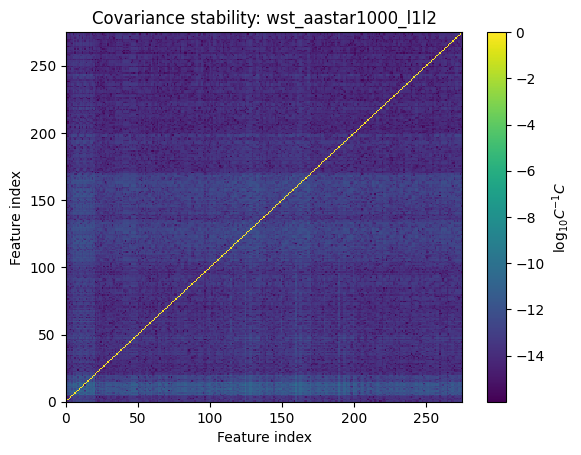

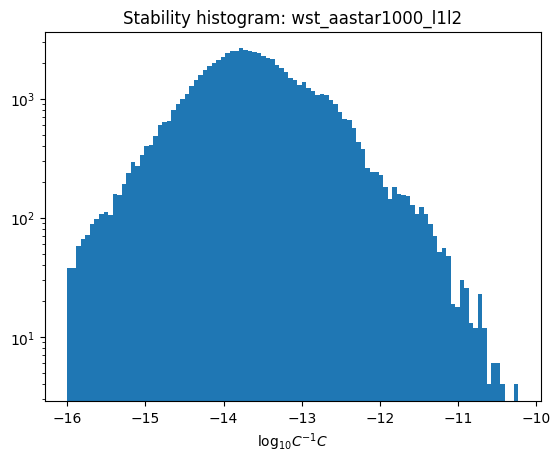

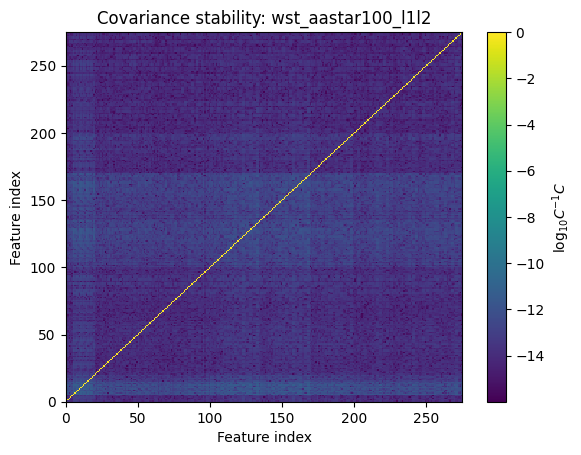

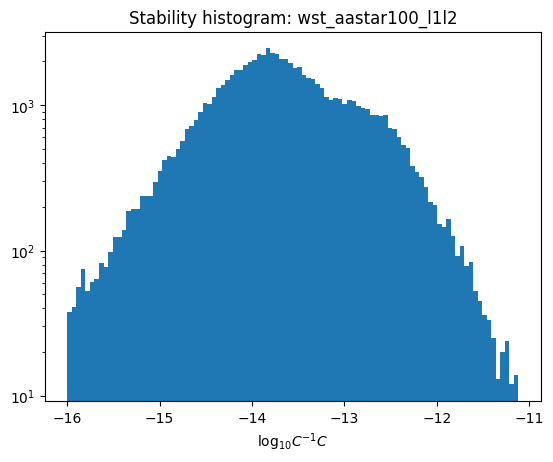

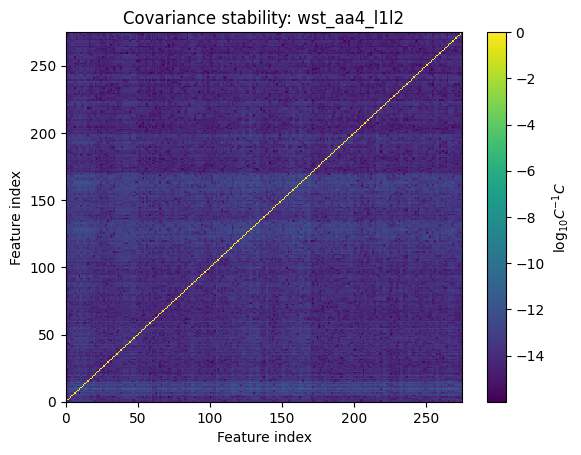

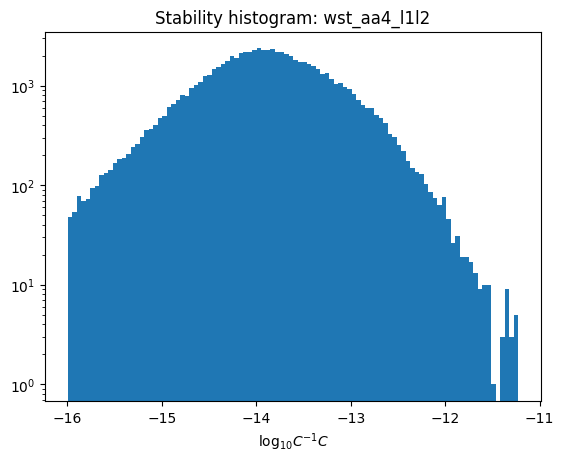

In [45]:
import matplotlib.pyplot as plt

# use the previously computed covs dict
for field, cov in covs.items():
    # compute I = log10(|C^-1 C| + eps)
    invC = np.linalg.inv(cov)
    I = np.log10(np.abs(invC @ cov) + 1e-16)
    # plot heatmap
    plt.figure()

    plt.pcolormesh(I)
    plt.colorbar().set_label('log$_{10} C^{-1}C$')
    plt.title(f"Covariance stability: {field}")
    plt.xlabel('Feature index')
    plt.ylabel('Feature index')

    # histogram of off-diagonal values
    plt.figure()
    offdiag = I[~np.eye(I.shape[0],dtype=bool)].ravel()
    plt.hist(offdiag, bins=100)
    plt.xlabel('log$_{10} C^{-1}C$')
    plt.yscale('log')
    plt.title(f"Stability histogram: {field}")

plt.show()

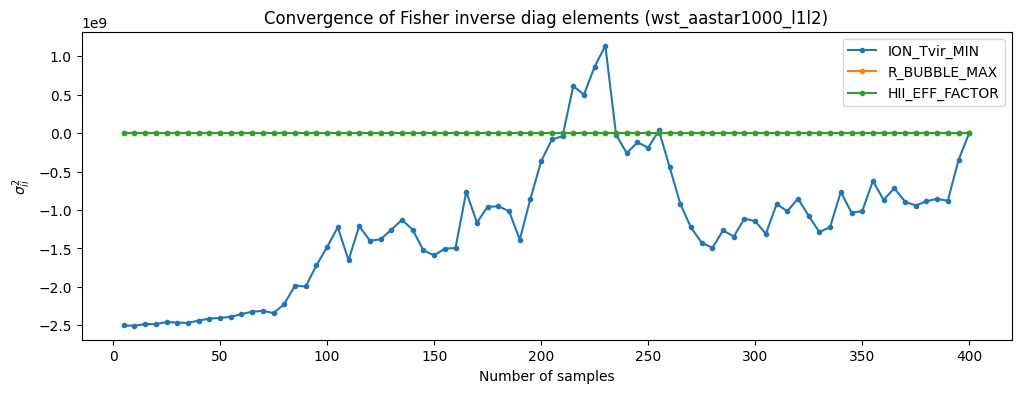

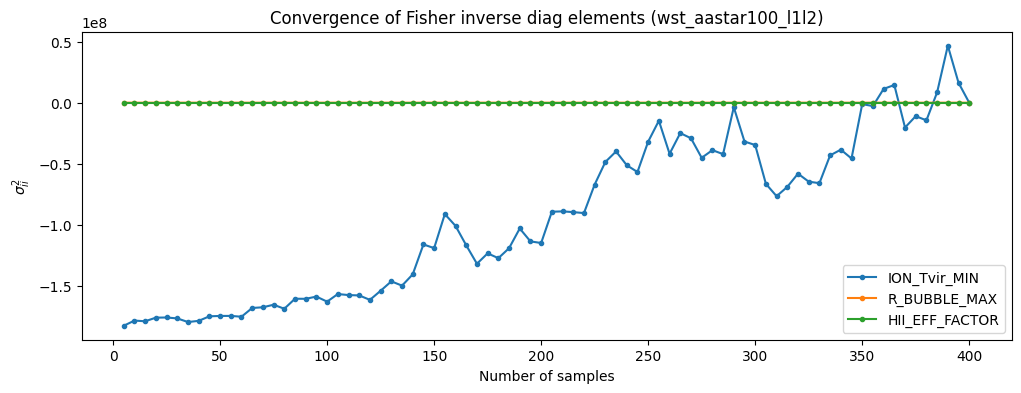

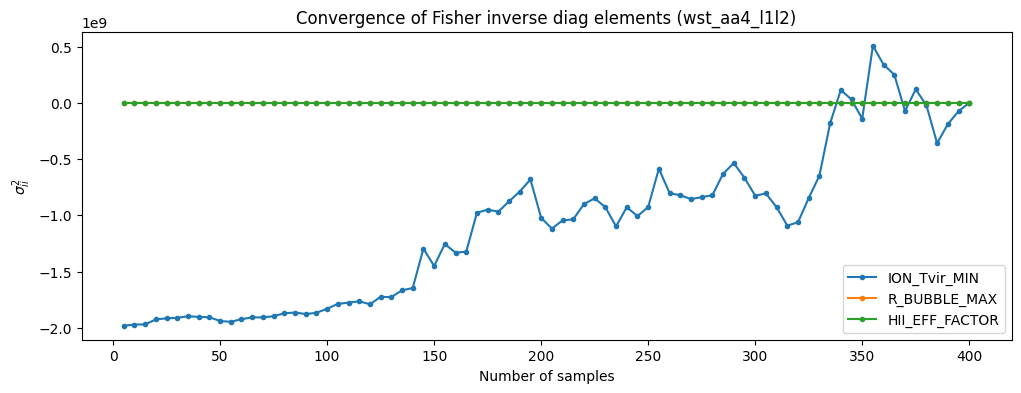

In [46]:
import matplotlib.pyplot as plt

fields = ['wst_aastar1000_l1l2', 'wst_aastar100_l1l2', 'wst_aa4_l1l2']
for field in fields:
    plt.figure(figsize=(12, 4))
    for i, param in enumerate(params):
        vals = [
            np.diag(Fisher_inv[field][k])[i]
            - np.diag(Fisher_inv[field][-1])[i]
            for k in range(len(samples))
        ]
        plt.plot(samples, vals, marker='.', label=param)
    plt.legend()
    plt.ylabel(r'$\sigma^2_{ii}$')
    plt.xlabel('Number of samples')
    plt.title(f'Convergence of Fisher inverse diag elements ({field})')
    plt.show()


We can now compute the data covariance $\mathbf{\Sigma}$ from the 400 samples:

We can now calculate the Fisher Matrix for different sub-samples to check convergence

In [29]:


# 1) Sample sizes
samples = np.arange(5, n_samp+1, 5)
nparams = len(params)

# 2) Prepare containers for each field
Fisher      = {field: np.zeros((samples.size, nparams, nparams)) 
               for field in fields}
Fisher_inv  = {field: np.zeros((samples.size, nparams, nparams)) 
               for field in fields}

# 3) Loop over fields
for field in fields:
    print(f"\n--- Convergence for {field} ---")
    cov = covs[field]                 # (n_features, n_features)
    cov_inv = np.linalg.inv(cov)

    # flatten derivatives once: shape (nparams, n_samp, n_features)
    deriv = derivs_all[field]        # shape (nparams, n_samp, …)
    deriv_flat = deriv.reshape(nparams, n_samp, -1)

    # 4) Build Fisher vs. sample size
    for k, sample_size in enumerate(samples):
        # average over first sample_size realisations
        dsamp = deriv_flat[:, :sample_size, :].mean(axis=1)  # (nparams, n_features)

        # fill Fisher matrix
        for i in range(nparams):
            for j in range(nparams):
                Fisher[field][k, i, j] = dsamp[i] @ (cov_inv @ dsamp[j])
        # invert Fisher
        Fisher_inv[field][k] = np.linalg.inv(Fisher[field][k])

    # 5) Inspect final (full‐sample) Fisher
    F_final = Fisher[field][-1]
    condF = np.linalg.cond(F_final)
    print("Final Fisher:\n", F_final)
    print("log10 cond(Final Fisher):", np.log10(condF))



--- Convergence for wst_aastar1000_l1l2 ---
Final Fisher:
 [[ 5.19701414e-08 -3.17793523e-05 -1.27997825e-04]
 [-3.17793523e-05  2.05606461e-02  7.84063365e-02]
 [-1.27997825e-04  7.84063365e-02  3.17888550e-01]]
log10 cond(Final Fisher): 8.930257251378046

--- Convergence for wst_aastar100_l1l2 ---
Final Fisher:
 [[ 3.49380474e-08 -5.48350760e-06 -3.91228117e-05]
 [-5.48350760e-06  1.44290505e-02  2.49367469e-02]
 [-3.91228117e-05  2.49367469e-02  7.51078485e-02]]
log10 cond(Final Fisher): 7.192206334930528

--- Convergence for wst_aa4_l1l2 ---
Final Fisher:
 [[ 7.01787654e-08 -3.67252444e-05 -1.73913632e-04]
 [-3.67252444e-05  2.04714846e-02  9.14734794e-02]
 [-1.73913632e-04  9.14734794e-02  4.34111845e-01]]
log10 cond(Final Fisher): 8.957245383983919


This is to be explicit, but we can just put this all into a function as:

In [ ]:
def get_fisher(derivatives, fiducial, nparams):
    """ Calculates the fisher matrix for different number of derivative samples. This function also 
        plots the 'identity' matrix derived for multiplying the covariance by its inverse - we also 
        include a histogram of this 'identity' matrix to see the zero-error.

    Parameters
    ----------
    derivatives : numpy.array
        An array containing the derivatives of a given statistic, with dimensions of 
        [nparams,nsamples,ncoefficients]
    fiducial : numpy.array
        Contains the fiducial simulation's statistic, with which we calculate the
        covariance. It has dimensions [nsamples,ncoefficients].
    nparams : int
        The number of parameters for which a derivative has been calculated.
    
    Returns
    -------
    Fisher : numpy.array
        Fisher matrix for a given number of sample used to calculate derivatives.
        Dimensions of [len(samples), nparams, nparams]
        
    Fisher_Inv : numpy.array
        Inverse of the Fisher matrix,having dimensions of [len(samples), nparams, nparams].
    samples : numpy.array
        Contains the number of samples of derivatives used to calculate Fisher and Fisher_Inv
    """
    import numpy
    # Maximum number of derivative samples that can be used 
    max_samples = len(derivatives[0])
    
    ## Whitening step ##
    std_fid = np.std(fiducial,axis=0)
    white_fid = fiducial/std_fid
    #The covariance
    covariance = np.cov(white_fid,rowvar=False)
    # Whitening the derivatives
    derivatives_white = derivatives.reshape((nparams,max_samples,-1))/std_fid
    print(('Condition Number: 10^%.3f')%(np.log10(np.linalg.cond(covariance))))
    # How many samples to use
    samples = np.arange(5,max_samples+50,5)
    # Initialising Fishers 
    Fisher = np.zeros((len(samples),nparams,nparams))
    Fisher_Inv = np.zeros((len(samples),nparams,nparams))

    # Calculating the Fisher matrix for a given sample of derivatives 
    for k,sample_size in enumerate(samples):
        deriv_sample = np.mean(derivatives_white[:,:sample_size,:],axis=1)
        F_ij = np.zeros((nparams,nparams))
        for i in range(nparams):
            for j in range(nparams):
                parm_i_ps = (deriv_sample)[i]
                parm_j_ps = (deriv_sample)[j]        
                FIJ = np.dot(parm_i_ps, np.dot(np.linalg.inv(covariance),parm_j_ps))
                F_ij[i,j] = FIJ
        F_ij_inv = np.linalg.inv(F_ij)  
        Fisher[k,:,:]= F_ij
        Fisher_Inv[k,:,:] = F_ij_inv
    return Fisher,Fisher_Inv,samples

In [ ]:
import numpy as np

def get_fisher(derivatives, fiducial, nparams):
    """
    Calculates the Fisher matrix (and its inverse) as a function of sample size,
    using the provided derivatives and fiducial statistic.

    Parameters
    ----------
    derivatives : np.ndarray
        Shape (nparams, n_samp, ..., ...). Finite‐difference derivatives of your statistic.
    fiducial : np.ndarray
        Shape (n_samp, ..., ...). Fiducial samples of your statistic.
    nparams : int
        Number of parameters.

    Returns
    -------
    Fisher : np.ndarray
        Array of shape (n_steps, nparams, nparams).
    Fisher_inv : np.ndarray
        Inverses, same shape.
    samples : np.ndarray
        The sample‐size values used.
    """
    # Number of realisations
    n_samp = fiducial.shape[0]

    # --- Flatten feature dims ---
    fid_flat   = fiducial.reshape(n_samp, -1)               # (n_samp, n_features)
    deriv_flat = derivatives.reshape(nparams, n_samp, -1)   # (nparams, n_samp, n_features)

    # --- Whitening fiducial and build covariance ---
    std_fid  = np.std(fid_flat, axis=0)                     # (n_features,)
    white_fid = fid_flat / std_fid[np.newaxis, :]           # (n_samp, n_features)
    cov       = np.cov(white_fid, rowvar=False)             # (n_features, n_features)
    cov_inv   = np.linalg.inv(cov)

    # --- Whitening derivatives ---
    deriv_white = deriv_flat / std_fid[np.newaxis, np.newaxis, :]  # broadcast

    # --- Sample‐size grid ---
    samples = np.arange(5, n_samp+1, 5)
    n_steps = samples.size

    # --- Allocate output arrays ---
    Fisher     = np.zeros((n_steps, nparams, nparams))
    Fisher_inv = np.zeros_like(Fisher)

    # --- Build Fisher vs sample size ---
    for k, s in enumerate(samples):
        # average the first s realisations for each parameter
        dsamp = deriv_white[:, :s, :].mean(axis=1)        # (nparams, n_features)
        # fill Fisher matrix
        for i in range(nparams):
            for j in range(nparams):
                Fisher[k, i, j] = dsamp[i] @ (cov_inv @ dsamp[j])
        Fisher_inv[k] = np.linalg.inv(Fisher[k])

    return Fisher, Fisher_inv, samples


Plot the resulting Gaussian distribution with appropriate covariance

In [ ]:
fid

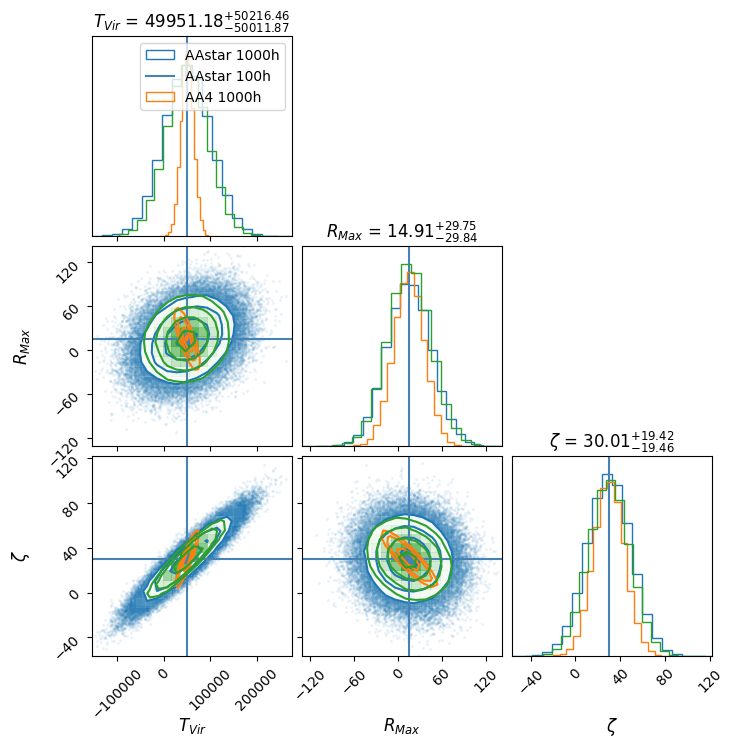

In [35]:
import corner
import matplotlib.pyplot as plt

# draw posterior samples for each configuration
f1 = np.random.multivariate_normal(
    [10**4.7, 15, 30],
    Fisher_inv['wst_aastar1000_l1l2'][-1],
    size=100000
)
f2 = np.random.multivariate_normal(
    [10**4.7, 15, 30],
    Fisher_inv['wst_aastar100_l1l2'][-1],
    size=100000
)
f3 = np.random.multivariate_normal(
    [10**4.7, 15, 30],
    Fisher_inv['wst_aa4_l1l2'][-1],
    size=100000
)

# first plot (AAstar 1000h)
fig = corner.corner(
    f1,
    labels=Fisher_Param,
    truths=fid,
    color='C0',
    label_kwargs={'fontsize':12},
    show_titles=True,
    title_fmt='.2f'
)
# overlay AAstar 100h contours
corner.corner(
    f2,
    fig=fig,
    color='C1',
    plot_datapoints=False,
    fill_contours=False
)
# overlay AA4 1000h contours
corner.corner(
    f3,
    fig=fig,
    color='C2',
    plot_datapoints=False,
    fill_contours=False
)

# add legend manually on the first subplot
ax0 = fig.get_axes()[0]
ax0.legend(['AAstar 1000h', 'AAstar 100h', 'AA4 1000h'], loc='upper right')


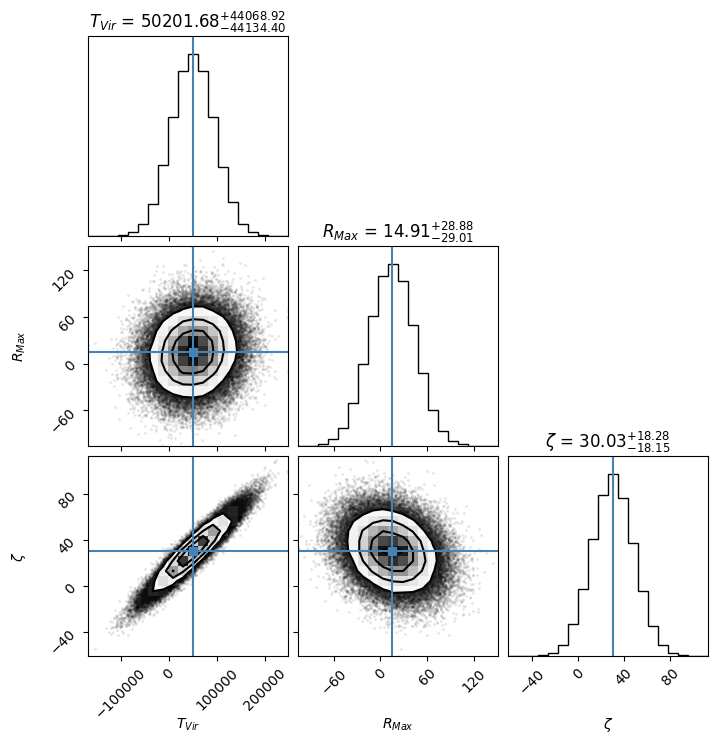

In [36]:
import corner
import numpy as np
import matplotlib.pyplot as plt

# draw the AA4 1000 h posterior
fisher_data = np.random.multivariate_normal(
    [10**4.7, 15, 30],
    Fisher_inv['wst_aa4_l1l2'][-1],
    size=100000
)

# single‐panel corner plot
corner.corner(
    fisher_data,
    labels=Fisher_Param,
    truths=fid,
    show_titles=True,
    title_fmt='.2f'
)
plt.show()


In [44]:
for field, inv_matrices in Fisher_inv.items():
    # take the full-sample (last) inverse Fisher
    inv_f = inv_matrices[-1]
    print(inv_f)
    out_path = os.path.join('/mesopsl3/home/ihothi/ska_eor_inference-main/output', f'Fisher_inv_{field}.txt')
    # save as plain text
    np.savetxt(out_path, inv_f, header=f'Inverse Fisher matrix for {field}')
    print(f"Saved inverse Fisher for {field} to {out_path}")

[[ 2.52489837e+09  4.31942017e+05  9.10113023e+05]
 [ 4.31942017e+05  8.92265167e+02 -4.61532952e+01]
 [ 9.10113023e+05 -4.61532952e+01  3.80986350e+02]]
Saved inverse Fisher for wst_aastar1000_l1l2 to /mesopsl3/home/ihothi/ska_eor_inference-main/output/Fisher_inv_wst_aastar1000_l1l2.txt
[[ 1.85231503e+08 -2.26075075e+05  1.71544711e+05]
 [-2.26075075e+05  4.38533213e+02 -2.63358421e+02]
 [ 1.71544711e+05 -2.63358421e+02  1.90108145e+02]]
Saved inverse Fisher for wst_aastar100_l1l2 to /mesopsl3/home/ihothi/ska_eor_inference-main/output/Fisher_inv_wst_aastar100_l1l2.txt
[[ 1.99860845e+09  1.32256242e+05  7.72813090e+05]
 [ 1.32256242e+05  8.44359348e+02 -1.24933988e+02]
 [ 7.72813090e+05 -1.24933988e+02  3.38232830e+02]]
Saved inverse Fisher for wst_aa4_l1l2 to /mesopsl3/home/ihothi/ska_eor_inference-main/output/Fisher_inv_wst_aa4_l1l2.txt


In [39]:
ls

compute_statistic.py                    LICENSE         README.md
Fisher_Tutorial.ipynb                   load_sim.ipynb
Fisher_Tutorial_Memory_Efficient.ipynb  move2h5py.py


In [40]:
pwd


'/mesopsl3/home/ihothi/ska_eor_inference-main'